<a href="https://colab.research.google.com/github/DataAnalytics808/DASC-522-demo-repository/blob/main/demos/Week_07_2_Binary_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


##Binary Classification





### Learning Objectives:

After doing this Colab, you'll know how to:

  * Convert a regression question into a classification question.
  * Modify the classification threshold and determine how that modification influences the model.
  * Experiment with different classification metrics to determine your model's effectiveness.

### The Dataset
  
Like several of the previous Colabs, this Colab uses the [California Housing Dataset](https://developers.google.com/machine-learning/crash-course/california-housing-data-description).

### Call the import statements

The following code imports the necessary modules.

In [ ]:
#title Load the imports

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers
from matplotlib import pyplot as plt

# The following lines adjust the granularity of reporting.
pd.options.display.max_rows = 10
pd.options.display.float_format = "{:.1f}".format
# tf.keras.backend.set_floatx('float32')

print("Ran the import statements.")

Ran the import statements.


### Load the datasets from the internet

The following code cell loads the separate .csv files and creates the following two pandas DataFrames:

* `train_df`, which contains the training set
* `test_df`, which contains the test set

In [ ]:
train_df = pd.read_csv("https://download.mlcc.google.com/mledu-datasets/california_housing_train.csv")
test_df = pd.read_csv("https://download.mlcc.google.com/mledu-datasets/california_housing_test.csv")
train_df = train_df.reindex(np.random.permutation(train_df.index)) # shuffle the training set

train_df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
11644,-121.3,38.0,41.0,930.0,191.0,463.0,185.0,3.4,90600.0
13288,-121.9,38.3,2.0,7747.0,1133.0,3481.0,1083.0,6.1,181000.0
11811,-121.3,38.6,23.0,1947.0,409.0,866.0,400.0,2.7,156800.0
1863,-117.3,35.1,32.0,671.0,166.0,856.0,114.0,2.6,53300.0
9557,-119.3,36.3,16.0,3331.0,839.0,1955.0,763.0,1.6,86600.0


### Create a binary label

In classification problems, the label for every example must be either 0 or 1. Unfortunately, the natural label in the California Housing Dataset, `median_house_value`, contains floating-point values like 80,100 or 85,700 rather than 0s and 1s, while the normalized version of `median_house_values` contains floating-point values primarily between -3 and +3.

Your task is to create a new column named `median_house_value_is_high` in both the training set and the test set . If the `median_house_value` is higher than a certain arbitrary value (defined by `threshold`), then set `median_house_value_is_high` to 1. Otherwise, set `median_house_value_is_high` to 0.

**Hint:** The cells in the `median_house_value_is_high` column must each hold `1` and `0`, not `True` and `False`. To convert `True` and `False` to  `1` and `0`, call the pandas DataFrame function `astype(float)`.

In [ ]:
# We arbitrarily set the threshold to 265,000, which is
# the 75th percentile for median house values.  Every neighborhood
# with a median house price above 265,000 will be labeled 1,
# and all other neighborhoods will be labeled 0.
threshold = 265000

y_train = (train_df["median_house_value"] > threshold).astype(float)
y_test  = (test_df["median_house_value"]  > threshold).astype(float)

print(y_train.head(20))

import statistics
print(statistics.mean(y_train))

# 0 is majority class


11644   0.0
13288   0.0
11811   0.0
1863    0.0
9557    0.0
         ..
7107    0.0
15134   0.0
1252    0.0
8203    0.0
9897    0.0
Name: median_house_value, Length: 20, dtype: float64
0.2498235294117647


###Create X_train, X_test

In [ ]:
train_df.describe()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,17000.0,17000.0,17000.0,17000.0,17000.0,17000.0,17000.0,17000.0,17000.0
mean,-119.6,35.6,28.6,2643.7,539.4,1429.6,501.2,3.9,207300.9
std,2.0,2.1,12.6,2179.9,421.5,1147.9,384.5,1.9,115983.8
min,-124.3,32.5,1.0,2.0,1.0,3.0,1.0,0.5,14999.0
25%,-121.8,33.9,18.0,1462.0,297.0,790.0,282.0,2.6,119400.0
50%,-118.5,34.2,29.0,2127.0,434.0,1167.0,409.0,3.5,180400.0
75%,-118.0,37.7,37.0,3151.2,648.2,1721.0,605.2,4.8,265000.0
max,-114.3,42.0,52.0,37937.0,6445.0,35682.0,6082.0,15.0,500001.0


In [ ]:
X_train = pd.concat( [train_df["median_income" ], train_df["total_rooms" ]], axis = 1)

X_test  = pd.concat( [test_df["median_income" ],  test_df["total_rooms" ]],  axis = 1)

# X_train.describe()
X_test.describe()

,median_income,total_rooms
count,3000.0,3000.0
mean,3.8,2599.6
std,1.9,2155.6
min,0.5,6.0
25%,2.5,1401.0
50%,3.5,2106.0
75%,4.7,3129.0
max,15.0,30450.0


###Common formatting options

In [ ]:
# ------ Common formating options ---------
plt.style.use('seaborn-v0_8-whitegrid')

SMALL_SIZE = 20
MEDIUM_SIZE = 30
BIGGER_SIZE = 40

plt.rc('font', size=SMALL_SIZE)           # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)      # fontsize of the axes title
plt.rc('axes', labelsize=BIGGER_SIZE)     # fontsize of the x and y labels
plt.rc('xtick', labelsize=MEDIUM_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=MEDIUM_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=MEDIUM_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)   # fontsize of the figure title

plt.rcParams["figure.figsize"] = (15,10)
# ------ end format ---------



### Logistic regression

In [ ]:
[X_train.shape[1],]

[2]

Optimization terminated successfully.
         Current function value: 0.629149
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:     median_house_value   No. Observations:                17000
Model:                          Logit   Df Residuals:                    16998
Method:                           MLE   Df Model:                            1
Date:                Thu, 26 Mar 2026   Pseudo R-squ.:                 -0.1192
Time:                        00:22:16   Log-Likelihood:                -10696.
converged:                       True   LL-Null:                       -9556.4
Covariance Type:            nonrobust   LLR p-value:                     1.000
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
median_income     0.0626      0.007      9.521      0.000       0.050       0.076
total_rooms      -0.

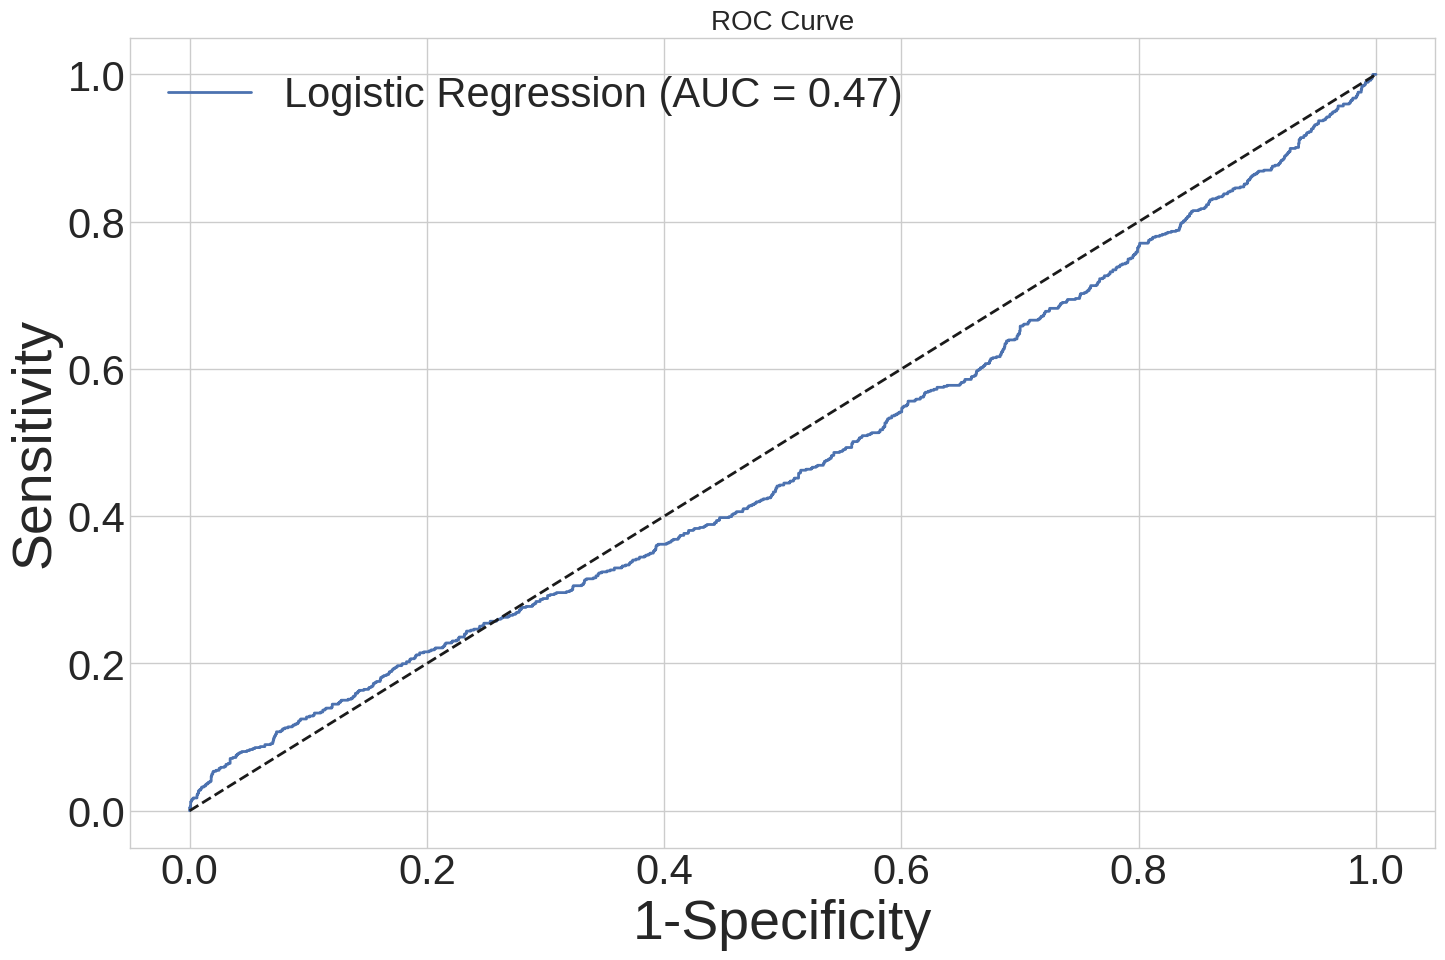

              precision    recall  f1-score   support

         0.0     0.7574    0.9445    0.8407      2254
         1.0     0.3386    0.0858    0.1369       746

    accuracy                         0.7310      3000
   macro avg     0.5480    0.5152    0.4888      3000
weighted avg     0.6533    0.7310    0.6657      3000



In [ ]:
import statsmodels.api as sm

model_1=sm.Logit(y_train, X_train).fit()
print(model_1.summary())
print('---')
print(model_1.summary2())


print('---')

#  Train set:  Confusion Matrix

cm = model_1.pred_table() # this gives confusion matrix
print(cm)


# metrics on test dataset ---------

#predictions
predictions=model_1.predict(X_test)
print(predictions)

# AUC & ROC
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.metrics import auc

fpr, tpr, t = roc_curve(      y_test, predictions)
logit_roc_auc = roc_auc_score(y_test, predictions)

# -------------
plt.plot(fpr, tpr,
         linewidth = 2,
         label='Logistic Regression (AUC = %0.2f)' % logit_roc_auc)

plt.plot([0,1],[0,1], 'k--', linewidth = 2)
plt.xlabel('1-Specificity')
plt.ylabel('Sensitivity')
plt.title('ROC Curve')
plt.legend()
plt.show();

# classification report needs binary values
from sklearn.metrics import classification_report
predictions = np.round(predictions) # classification_report needs a binary input
report = classification_report(y_test, predictions, digits=4)
print(report)

### "All-in-one" neural network with normalization and metrics

Number of features is 2
 
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


136/136 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7968 - loss: 0.5333 - val_accuracy: 0.8371 - val_loss: 0.4296
Epoch 2/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8296 - loss: 0.4162 - val_accuracy: 0.8406 - val_loss: 0.3859
Epoch 3/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8304 - loss: 0.4019 - val_accuracy: 0.8429 - val_loss: 0.3818
Epoch 4/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8317 - loss: 0.3992 - val_accuracy: 0.8424 - val_loss: 0.3809
Epoch 5/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8320 - loss: 0.3980 - val_accuracy: 0.8432 - val_loss: 0.3799
Epoch 6/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8313 - loss: 0.3976 - val_accuracy: 0.8435 - val_loss: 0.3799
Epoch 7/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8322 - loss: 0.3972 - val_accuracy: 0.8432 - val_loss: 0.3800
Epoch 8/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8330 - loss: 0.3970 - val_accuracy: 0.8432 - val_

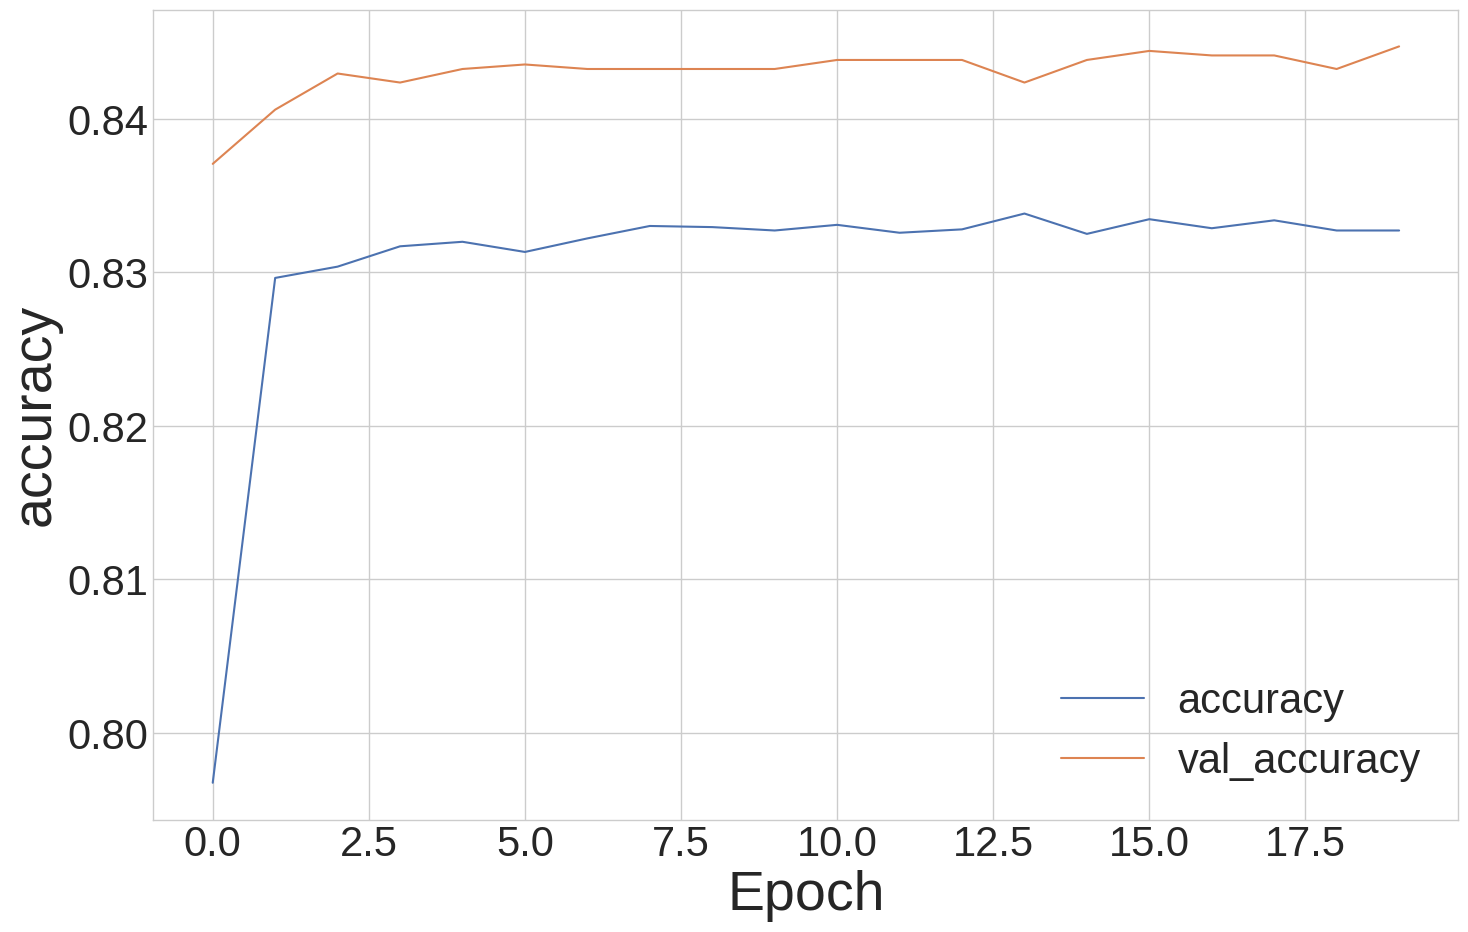

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
AUC = 0.8283355654885803
              precision    recall  f1-score   support

         0.0     0.8393    0.9614    0.8962      2254
         1.0     0.7919    0.4437    0.5687       746

    accuracy                         0.8327      3000
   macro avg     0.8156    0.7026    0.7325      3000
weighted avg     0.8275    0.8327    0.8148      3000



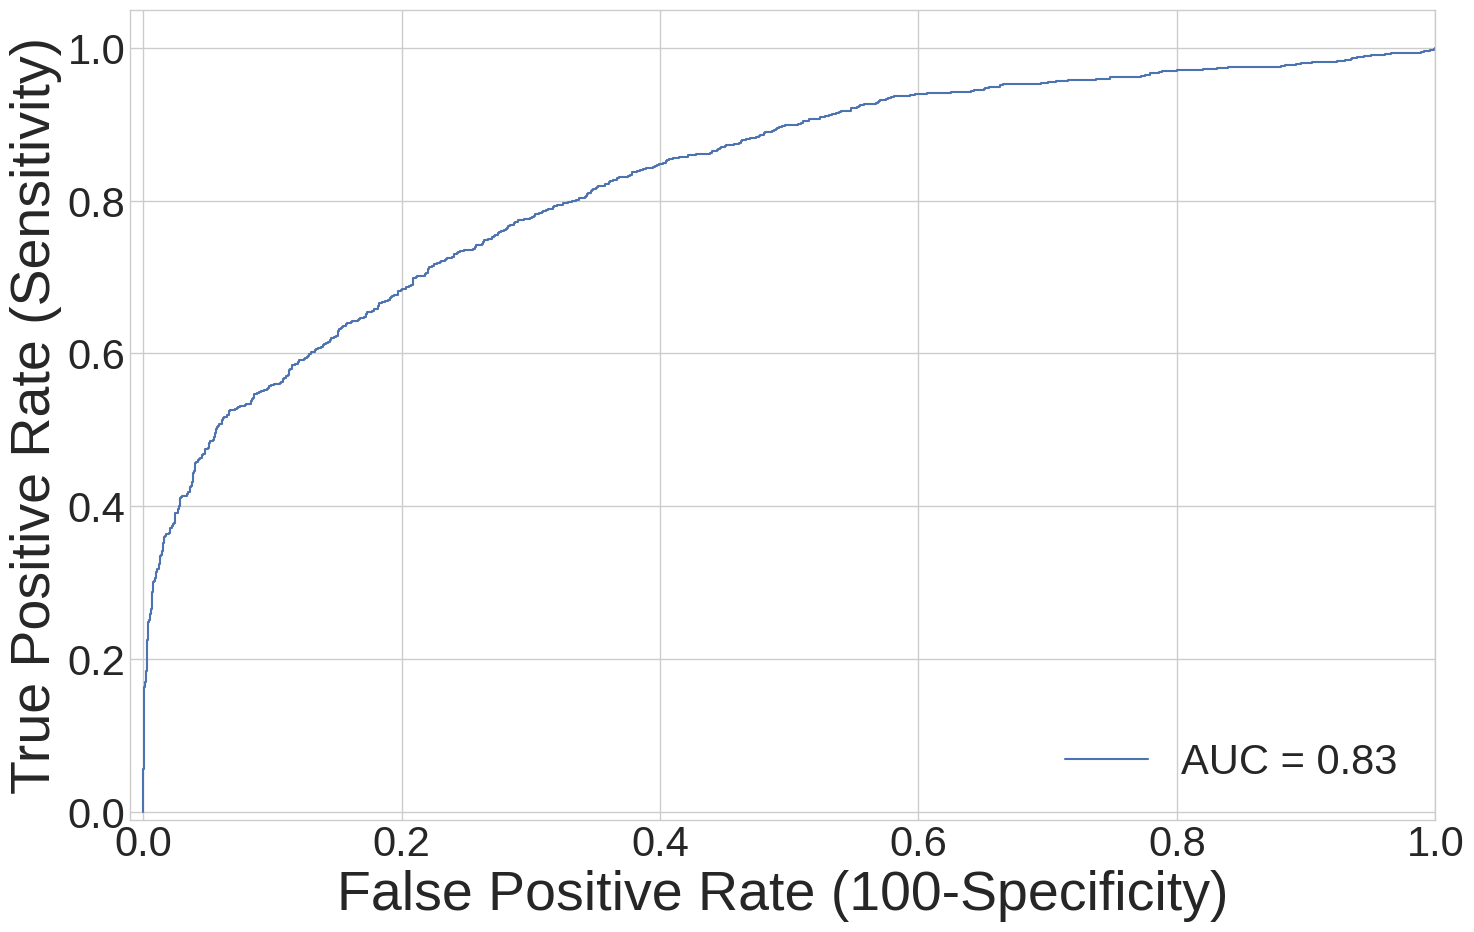

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, regularizers
from tensorflow.keras.layers import Normalization # Import Normalization from the correct location

# X_train = np.random.random((1000, 20))  # Example shape (1000 samples, 20 features)
# y_train = np.random.randint(0, 2, (1000,))  # Example binary target (0 or 1)


# The following variables are the hyperparameters.
learning_rate = 0.001
epochs = 20
batch_size = 100
classification_threshold = 0.5


# Establish the metrics the model will measure.
METRICS = [tf.keras.metrics.BinaryAccuracy(name='accuracy', threshold=classification_threshold)]

# Normalizer: a stubborn error occurs if a dataframe is fed into .adapt.
# Must convert to numpy array with X_train.values
# The dataframe version of X_train is still used to train the NN
X_train_values = X_train.values
number_of_inputs= X_train_values.shape[1]
normalizer = Normalization(input_shape=[number_of_inputs,])
normalizer.adapt(X_train_values)

# Create Neural Network
print(f"Number of features is {number_of_inputs}")
print(" ")
model = keras.Sequential([normalizer,
                          layers.Dense(10, activation='relu', input_dim=number_of_inputs),
                          layers.Dense(10, activation='relu'),
                          layers.Dense(1, activation='sigmoid') ]) # output layer for regression


#Compile
model.compile(optimizer=tf.keras.optimizers.RMSprop(learning_rate=learning_rate),
              loss=tf.keras.losses.BinaryCrossentropy(),
              metrics=METRICS)

history = model.fit(x=X_train,
                    y=y_train,
                    batch_size=batch_size,
                    epochs=epochs,
                    validation_split = 0.2)  # Calculate validation results on 20% of the training data)

# Extract training history
epochs = history.epoch
hist = pd.DataFrame(history.history)

# plot curve
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')

# plt.ylim([1,y_lim])
plt.xlabel('Epoch')
plt.ylabel('accuracy')
plt.legend()
plt.grid(True)
plt.show()


# -------------- Metrics on holdout set

# prepare features
my_holdout = X_test
my_holdout_label = y_test

# predict using model
y_pred = model.predict(my_holdout)


# AUC

from sklearn.metrics import roc_curve
from sklearn.metrics import auc
fpr, tpr, thresholds = roc_curve(my_holdout_label, y_pred)
AUC_from_fn = auc(fpr, tpr)
print(f"AUC = {AUC_from_fn}")

# ROC curve
fpr, tpr, thresholds = roc_curve(my_holdout_label, y_pred)
plt.plot(fpr, tpr, label='AUC = %0.2f' % AUC_from_fn)
plt.xlabel('False Positive Rate (100-Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.xlim([-0.01, 1.0])
plt.ylim([-0.01, 1.05])
plt.legend(loc="lower right")

# accuracy, precision, recall, F1 from classification_report
from sklearn.metrics import classification_report
y_pred = np.round(y_pred) # classification_report needs a binary input
report = classification_report(my_holdout_label, y_pred, digits=4)
print(report)

## compare to trivial model
## be sure to tune model


### Hyperparameter sweep: classification threshold

Experiment with different values for `classification_threshold` in the code cell within "Invoke the creating, training, and plotting functions."  What value of `classification_threshold` produces the highest accuracy?

Number of features is 2
 
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


136/136 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.2642 - loss: 0.5066 - precision: 0.2527 - recall: 0.9953 - val_accuracy: 0.3526 - val_loss: 0.4201 - val_precision: 0.2773 - val_recall: 0.9836
Epoch 2/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4809 - loss: 0.4118 - precision: 0.3182 - recall: 0.9455 - val_accuracy: 0.5547 - val_loss: 0.3851 - val_precision: 0.3545 - val_recall: 0.9437
Epoch 3/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5527 - loss: 0.4014 - precision: 0.3494 - recall: 0.9187 - val_accuracy: 0.5612 - val_loss: 0.3816 - val_precision: 0.3578 - val_recall: 0.9426
Epoch 4/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5608 - loss: 0.3991 - precision: 0.3538 - recall: 0.9196 - val_accuracy: 0.5462 - val_loss: 0.3808 - val_precision: 0.3510 - val_recall: 0.9531
Epoch 5/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5556 - loss: 0.3979 - precision: 0.3514 - recall: 0.9231 - val_accuracy: 0.5559 - val_loss: 0.3801 - val_

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


136/136 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.3555 - loss: 0.5441 - precision: 0.2748 - recall: 0.9655 - val_accuracy: 0.5900 - val_loss: 0.4480 - val_precision: 0.3716 - val_recall: 0.9179
Epoch 2/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6759 - loss: 0.4320 - precision: 0.4240 - recall: 0.8332 - val_accuracy: 0.7262 - val_loss: 0.4001 - val_precision: 0.4735 - val_recall: 0.8171
Epoch 3/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7231 - loss: 0.4086 - precision: 0.4673 - recall: 0.7834 - val_accuracy: 0.7441 - val_loss: 0.3872 - val_precision: 0.4938 - val_recall: 0.7995
Epoch 4/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7340 - loss: 0.4018 - precision: 0.4793 - recall: 0.7652 - val_accuracy: 0.7574 - val_loss: 0.3836 - val_precision: 0.5108 - val_recall: 0.7761
Epoch 5/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7416 - loss: 0.3998 - precision: 0.4886 - recall: 0.7587 - val_accuracy: 0.7553 - val_loss: 0.3826 - val_

...

136/136 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.7646 - loss: 0.5045 - precision: 0.9801 - recall: 0.0580 - val_accuracy: 0.8038 - val_loss: 0.4165 - val_precision: 0.9515 - val_recall: 0.2298
Epoch 2/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8092 - loss: 0.4115 - precision: 0.9366 - recall: 0.2525 - val_accuracy: 0.8256 - val_loss: 0.3880 - val_precision: 0.9333 - val_recall: 0.3283
Epoch 3/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8214 - loss: 0.4020 - precision: 0.9177 - recall: 0.3123 - val_accuracy: 0.8297 - val_loss: 0.3829 - val_precision: 0.9335 - val_recall: 0.3458
Epoch 4/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8246 - loss: 0.3988 - precision: 0.9118 - recall: 0.3291 - val_accuracy: 0.8350 - val_loss: 0.3808 - val_precision: 0.9171 - val_recall: 0.3763
Epoch 5/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8266 - loss: 0.3975 - precision: 0.9066 - recall: 0.3403 - val_accuracy: 0.8347 - val_loss: 0.3801 - val

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


136/136 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7593 - loss: 0.5408 - precision: 0.9840 - recall: 0.0362 - val_accuracy: 0.7735 - val_loss: 0.4436 - val_precision: 0.9663 - val_recall: 0.1008
Epoch 2/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7885 - loss: 0.4164 - precision: 0.9709 - recall: 0.1573 - val_accuracy: 0.8056 - val_loss: 0.3842 - val_precision: 0.9404 - val_recall: 0.2403
Epoch 3/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8039 - loss: 0.4014 - precision: 0.9631 - recall: 0.2227 - val_accuracy: 0.8059 - val_loss: 0.3829 - val_precision: 0.9406 - val_recall: 0.2415
Epoch 4/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8043 - loss: 0.4003 - precision: 0.9610 - recall: 0.2251 - val_accuracy: 0.8065 - val_loss: 0.3822 - val_precision: 0.9412 - val_recall: 0.2438
Epoch 5/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8048 - loss: 0.3996 - precision: 0.9636 - recall: 0.2263 - val_accuracy: 0.8147 - val_loss: 0.3821 - val_

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


136/136 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7504 - loss: 0.5299 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.7491 - val_loss: 0.4370 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7504 - loss: 0.4255 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.7500 - val_loss: 0.3974 - val_precision: 1.0000 - val_recall: 0.0035
Epoch 3/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7560 - loss: 0.4088 - precision: 0.9750 - recall: 0.0230 - val_accuracy: 0.7594 - val_loss: 0.3870 - val_precision: 0.9730 - val_recall: 0.0422
Epoch 4/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7665 - loss: 0.4029 - precision: 0.9866 - recall: 0.0651 - val_accuracy: 0.7724 - val_loss: 0.3826 - val_precision: 0.9759 - val_recall: 0.0950
Epoch 5/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7732 - loss: 0.4006 - precision: 0.9784 - recall: 0.0934 - val_accuracy: 0.7782 -

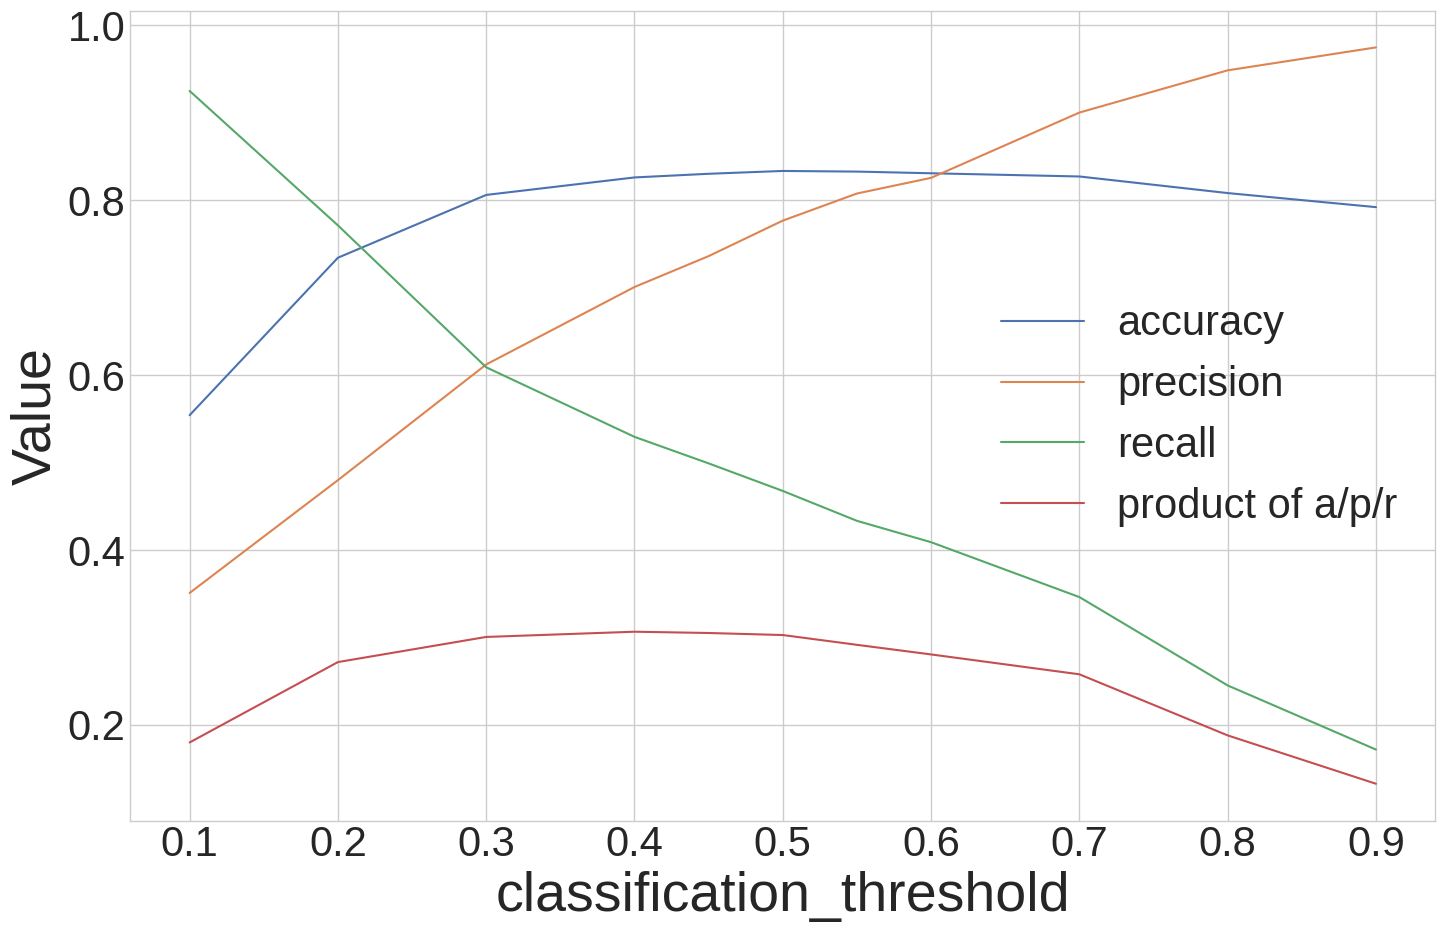

In [ ]:

# The following variables are the hyperparameters.
learning_rate = 0.001
epochs = 10
batch_size = 100
# classification_threshold = 0.52  % we are going to sweep this



ACC_list = []
PREC_list = []
RECALL_list = []
SUMMARY_list = []

classifs_to_try = [0.1, 0.2, 0.3, 0.4, 0.45, 0.5, 0.55, 0.6, 0.7, 0.8, 0.9]
# classifs_to_try = [0.45, 0.5, 0.55]

for classification_threshold in classifs_to_try:

  # --- start of model

  METRICS = [
        tf.keras.metrics.BinaryAccuracy(threshold=classification_threshold,  name='accuracy'),
        tf.keras.metrics.Precision(     thresholds=classification_threshold, name='precision'),
        tf.keras.metrics.Recall(        thresholds=classification_threshold, name='recall'),
  ]

  number_of_inputs= X_train.shape[1]
  print(f"Number of features is {number_of_inputs}")
  print(" ")
  model = keras.Sequential([normalizer,
                            layers.Dense(10, activation='relu', input_dim=number_of_inputs),
                            layers.Dense(10, activation='relu'),
                            layers.Dense(1, activation='sigmoid') ]) # output layer for regression


  #Compile
  model.compile(optimizer=tf.keras.optimizers.RMSprop(learning_rate = learning_rate),
                loss=tf.keras.losses.BinaryCrossentropy(),
                metrics=METRICS)

  history = model.fit(x=X_train,
                      y=y_train,
                      batch_size=batch_size,
                      epochs=epochs,
                      validation_split = 0.2)  # Calculate validation results on 20% of the training data)

  # --- end of model

  # Extract training history
  hist = pd.DataFrame(history.history)

  x=hist['accuracy']
  x=x[len(x)-1] #  last element is the final value
  ACC_list.append(x)

  y=hist['precision']
  y=y[len(y)-1] #  last element is the final value
  PREC_list.append(y)

  z=hist['recall']
  z=z[len(z)-1] #  last element is the final value
  RECALL_list.append(z)

  a=x*y*z
  SUMMARY_list.append(a)


plt.figure()
plt.xlabel("classification_threshold")
plt.ylabel("Value")

plt.plot(classifs_to_try, ACC_list, label='accuracy')
plt.plot(classifs_to_try, PREC_list, label='precision')
plt.plot(classifs_to_try, RECALL_list, label='recall')

plt.plot(classifs_to_try, SUMMARY_list, label='product of a/p/r')


plt.legend()

# discuss A, P & R at https://developers.google.com/machine-learning/crash-course/classification/accuracy
